In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.drop("Loan_ID", axis=1, inplace=True)

In [4]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [5]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])
df = pd.get_dummies(df, columns=["Property_Area"], dtype=int)
df = pd.get_dummies(df, columns=["Dependents"], dtype=int)

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Step 1: Check for categorical columns
print("Data types:")
print(X_train.dtypes)
print("\nSample data:")
print(X_train.head())

# Step 2: Encode categorical columns
le = LabelEncoder()

# Find categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print(f"\nCategorical columns: {list(categorical_cols)}")

# Encode each categorical column
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Step 3: Now run GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best score: {grid.best_score_:.4f}")


Data types:
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

Sample data:
    Gender Married Dependents Education Self_Employed  ApplicantIncome  \
83    Male     Yes          0  Graduate            No             6000   
90    Male     Yes          0  Graduate            No             2958   
227   Male     Yes          2  Graduate            No             6250   
482   Male     Yes          0  Graduate            No             2083   
464   Male      No          0  Graduate            No             4166   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
83              2250.0       265.0             360.0             1.0   
90              2900.0       131.0             360.0

In [9]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf=2,
    min_samples_split=20,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=20,
                       random_state=42)

In [17]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report

y_pred = model.predict(X_test)
print("Accuracy score in test:",accuracy_score(y_test,y_pred))

y_pred1 = model.predict(X_train)
print("Accuracy score in train:",accuracy_score(y_train,y_pred1))

print("confusion matrix:",confusion_matrix(y_test,y_pred))
precision = precision_score(y_test, y_pred, pos_label='Y')
recall = recall_score(y_test, y_pred, pos_label='Y')
f1 = f1_score(y_test, y_pred, pos_label='Y')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("classification report",classification_report(y_test,y_pred))

Accuracy score in test: 0.7073170731707317
Accuracy score in train: 1.0
confusion matrix: [[24 19]
 [17 63]]
Precision: 0.7683
Recall: 0.7875
F1 Score: 0.7778
classification report               precision    recall  f1-score   support

           N       0.59      0.56      0.57        43
           Y       0.77      0.79      0.78        80

    accuracy                           0.71       123
   macro avg       0.68      0.67      0.67       123
weighted avg       0.70      0.71      0.71       123



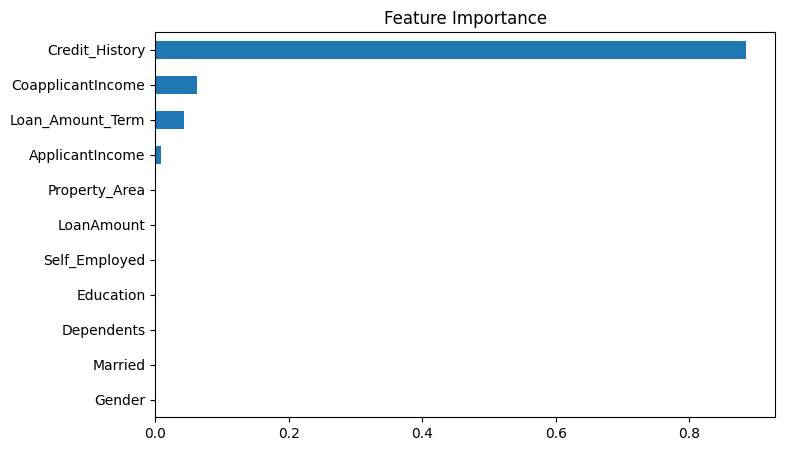

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)
import matplotlib.pyplot as plt

plt.title("Feature Importance")
plt.show()

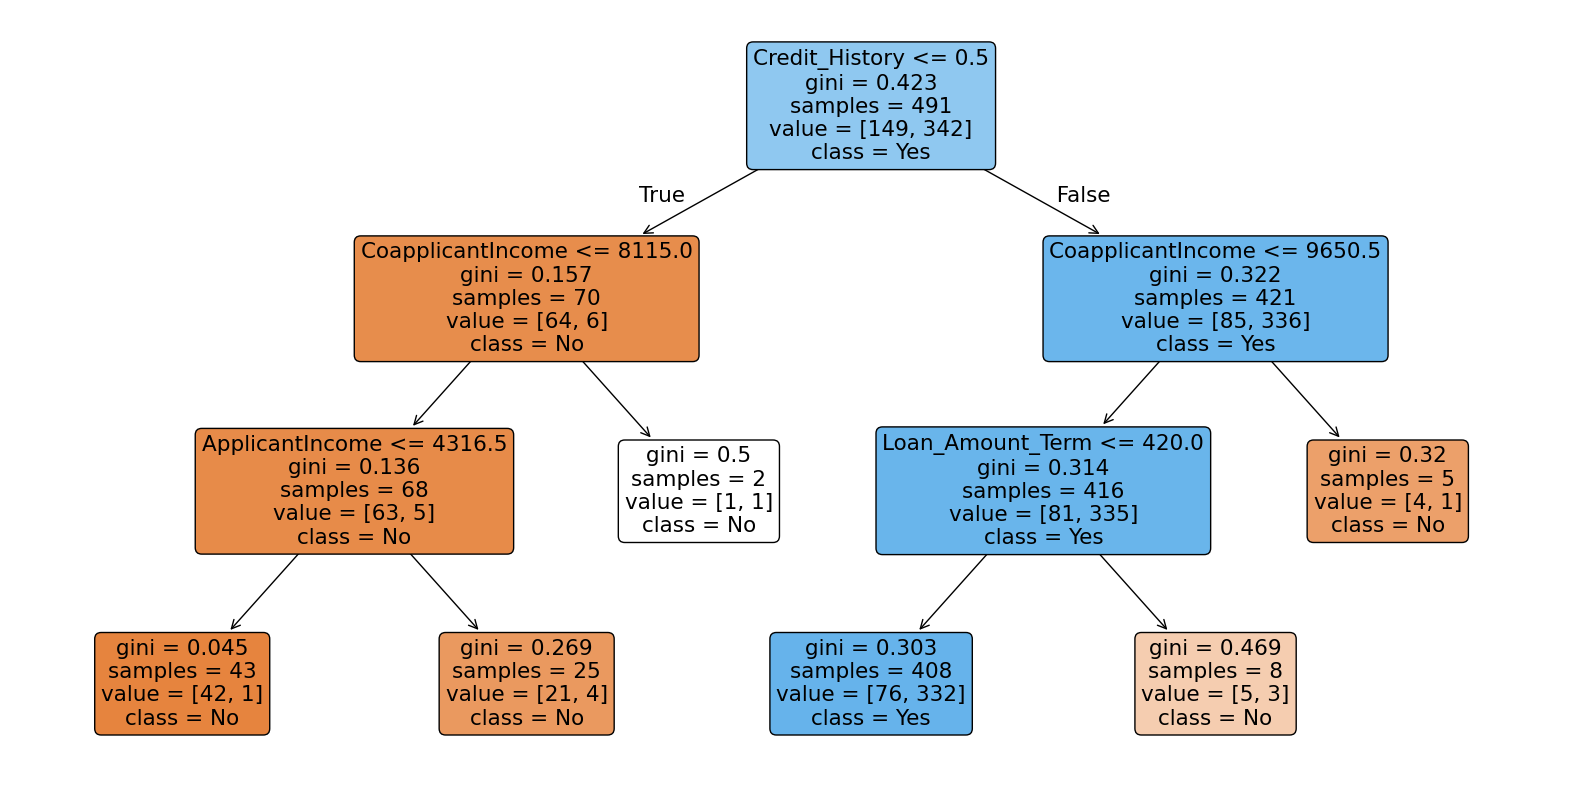

In [13]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

plt.show()

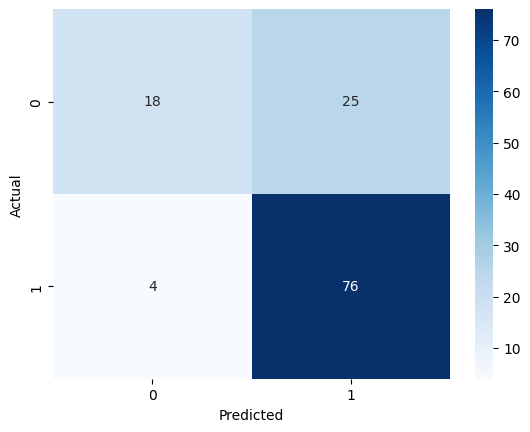

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

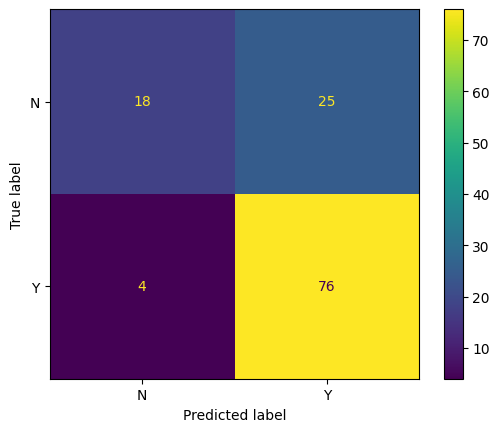

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)
plt.show()

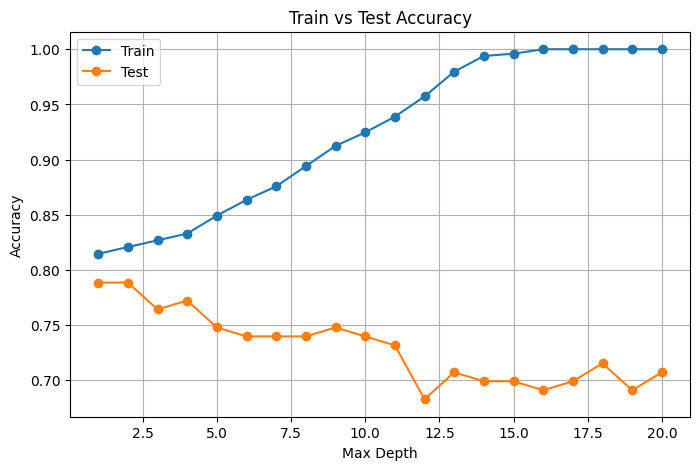

In [16]:
depths = []
train_acc = []
test_acc = []

for d in range(1,21):

    model = DecisionTreeClassifier(max_depth=d)

    model.fit(X_train,y_train)

    depths.append(d)

    train_acc.append(model.score(X_train,y_train))

    test_acc.append(model.score(X_test,y_test))

plt.figure(figsize=(8,5))

plt.plot(depths,train_acc,label="Train",marker="o")
plt.plot(depths,test_acc,label="Test",marker="o")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")

plt.legend()

plt.grid()

plt.show()